In [1]:
import numpy as np
import sys, os
from scipy.optimize import minimize as scipy_minimize
import matplotlib
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp

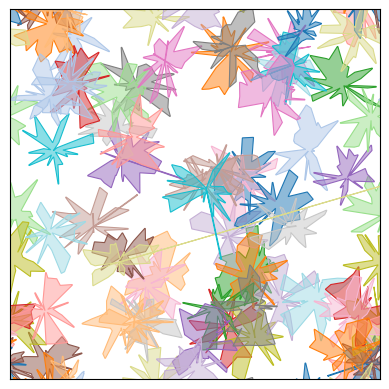

In [2]:
outdir = "/home/rdennis/Documents/Code/pyCudaPolygon/tests/roundedTestAreaEnergy"
N = 64
n = 32
seed = 42
kappa = 3.7
rho = 0.001 # TODO: This should be relative to the perimeter
m = pcp.model(size = N * n, seed = seed)
m.setModelEnum("softBody")
m.generateRandomPolygons(N, n)
m.setBiPerimeters(kappa)
m.setDelta(rho)
m.setStiffness(1)
m.setCompressibility(1)
# Ball-based neighbor scheme (default). initializeNeighborBall also takes
# care of the topology arrays (shapeId/next/prev) and the candidate buffer
# so no cell-grid init is needed.
m.initializeNeighborBall()
m.updateForceEnergy()
artists = m.drawBiarc()
plt.show()

In [3]:
m.minimizeFIRE(maxForceThreshold = 1e-14, progressBar = True)
m.setPhi(1.1)
print(m.getConstraintViolation())

FIRE:   0%|                       | 9147/100000000 [00:03<10:08:26, 2739.02it/s]

{'rmsAreaViolation': 4.872368567697774e-15, 'rmsEdgeViolation': 1.1254595766021736e-10, 'rmsPerimeterViolation': 1.125457126967045e-10}


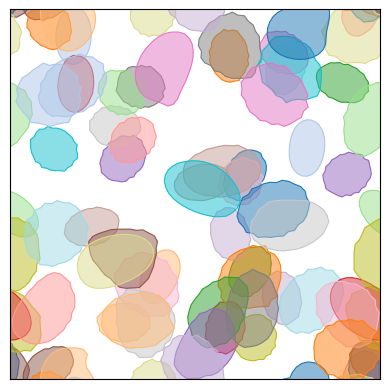

In [4]:
artists = m.drawBiarc()
plt.show()

In [5]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

{'rmsAreaViolation': 4.872368567697774e-15, 'rmsEdgeViolation': 1.1254595766021736e-10, 'rmsPerimeterViolation': 1.125457126967045e-10}


In [6]:
m.setModelEnum("rounded")
m.setMaxEdgeLength()
m.initializeNeighborBall()
m.updatePolygonGeometry()    # refresh live maxEdgeLength before first ball build
m.updateNeighborBall()
m.updateForceEnergy()
m.minimizeFIRE(maxSteps = 1, progressBar = True, shakeIter = 100)

FIRE: 100%|███████████████████████████████████████| 1/1 [00:00<00:00,  1.11it/s]

This may not have fully minimized


(6.190473048184593, 0.0005, 1, array([5., 5., 5.]))

In [7]:
print(m.getConstraintViolation())

{'rmsAreaViolation': 2.2187540492015364e-15, 'rmsEdgeViolation': 7.766466462731833e-15, 'rmsPerimeterViolation': 1.632749897878059e-15}


In [8]:
m.minimizeFIRE(dt = 1e-3, maxSteps = 1, progressBar = True, shakeIter = 100)

FIRE: 100%|███████████████████████████████████████| 1/1 [00:00<00:00,  1.10it/s]

This may not have fully minimized


(5.961701639578883, 0.001, 1, array([5., 5., 5.]))

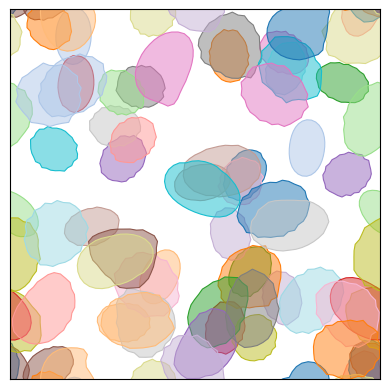

In [9]:
_ = m.drawBiarc()

In [ ]:
m.minimizeFIRE(dt = 1e-8, maxSteps = 10000, progressBar = True, shakeIter = 10000)

FIRE:  29%|████████▊                     | 2940/10000 [45:43<1:55:01,  1.02it/s]

In [ ]:
_ = m.drawBiarc()

In [ ]:
m.projectForce()
m.getMaxUnbalancedForce()

In [ ]:
m.projectForce()
m.getMaxUnbalancedForce()

In [ ]:
m.getEnergy()

In [ ]:
m.getEnergy()

In [ ]:
m.updatePolygonGeometry()
m.updateNeighborBall()
m.updateForceEnergy()

In [ ]:
m.saveModel("tooSlow")